# WaNet (Warping-based Backdoor Attack) — ResNet-50 (GTSRB)

**Threat model: data-poisoning / supply-chain.** An attacker injects a small fraction of poisoned samples; the model behaves normally on clean inputs but flips to a chosen target class whenever the trigger is present.

**Trigger = WaNet (Nguyen & Tran, ICLR 2021):** instead of *adding* a pattern, WaNet applies a smooth, fixed image **warp** (an elastic field that subtly displaces pixels). This is the *global structural* counterpart to the *localized additive* BadNets patch (Gu et al. 2017) and the *global additive* Blended trigger (Chen et al. 2017) — three qualitatively different trigger families in one benchmark.

The warp mechanic below is **ported verbatim from the authors' official code** (VinAIResearch/Warping-based_Backdoor_Attack-release, `train.py`) — control-grid construction, mean-abs normalization, bicubic upsample, and `grid_sample` settings are exactly theirs (only the field is seeded for reproducibility). **Scope: WaNet attack-only; noise-mode excluded in v1** (see the noise-mode cell). Defenses are future work.

**The two metrics:** **Clean Accuracy (CA)** (stealth of benign behavior) and **Attack Success Rate (ASR)** (fraction of *warped* non-target test images classified as the target). At 0% poisoning ASR should be near-chance — the control proving the warp only works *because of poisoning*.

## Experimental scope — v1
**v1 (current): two INDEPENDENT 1-D sweeps** — Block A varies poison rate at fixed warp strength `s`; Block B varies `s` at fixed poison rate. **v2 (future): a 2-D `s` × poison-rate floor grid** (see the `block_c_2d_grid_PLACEHOLDER` stub). The two 1-D sweeps locate each floor separately but assume the axes don't interact.

## Configuration & imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
import numpy as np
from PIL import Image
import os, json, random
import matplotlib.pyplot as plt

# ── WaNet configuration (cell 0) ────────────────────────────────────────
NUM_CLASSES   = 43
TARGET_LABEL  = 0            # all-to-one: warped images -> class 0 (configurable)
POISON_RATES  = [0.0, 0.0001, 0.00025, 0.0005, 0.001, 0.0025, 0.005, 0.01, 0.05, 0.10, 0.20]   # EXACT BadNets/Blended grid (comparability)

IMG_SIZE  = 224
WARP_K    = 4         # control-grid size (k x k); FIXED, never swept (analog of trigger key)
WARP_SEED = 1234      # seeds the fixed warp field; FIXED FOREVER, never swept
WARP_S    = 5         # Block A operating point: s=5 -> ~2.6px mean displacement at 224px, the
                      # genuinely SUBTLE choice from the calibration figure (s=10/5.1px is already
                      # visibly distorted, defeating WaNet's stealth premise). The official warp
                      # divides by input_height, so small s is sub-pixel at 224px — hence the
                      # rescaled grid. If ASR is weak at s=5 that is a FINDING (imperceptible warp
                      # too weak at high res), not a bug — nudge s up then.
WARP_S_GRID = [2, 5, 10, 20, 40]   # Block B sweep, rescaled UP for 224px (mean-abs-normalized
                                   # warp / input_height makes small s sub-pixel). Spans invisible
                                   # (2) -> subtle (5, the WARP_S operating point) -> visible (20)
                                   # -> distorted (40). (s=80 ~37px was a melted blob; dropped.)
RATE_FOR_STRENGTH_SWEEP = 0.05   # fixed poison rate for Block B (above the reliability floor)
GRID_RESCALE = 1      # opt.grid_rescale default in the official config.py

SEED          = 42
SEEDS         = [42, 123, 7]    # multi-seed averaging for the noisy low-rate floor
LOW_RATE_THRESHOLD = 0.005      # rates <= this are noisy (few poisoned imgs) -> run once per
                                # seed; which images get picked matters, so we average. Higher
                                # rates (and rate 0 control) run single-seed with seed 42 only.

MODEL_NAME  = 'resnet50'
MODEL_TITLE = 'ResNet-50'
DS_TITLE    = 'GTSRB'
DS_SHORT    = 'gtsrb'
CKPT_TAG    = ''   # checkpoint name infix ('' for gtsrb, '_bel' for bel)
BATCH_SIZE  = 64
NUM_EPOCHS  = 15
MODELS_DIR  = 'models'   # all trained checkpoints (.pth) are saved here

DATA_DIR   = 'dataset'
TRAIN_DIR  = os.path.join(DATA_DIR, 'Train')
TEST_CSV   = os.path.join(DATA_DIR, 'Test.csv')
TEST_DIR   = DATA_DIR
VAL_SPLIT  = 0.2

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
print(f'{MODEL_TITLE} | {DS_TITLE} | classes={NUM_CLASSES} | epochs={NUM_EPOCHS} | batch={BATCH_SIZE}')
print(f'WaNet: s_A={WARP_S}, s grid={WARP_S_GRID}, rate_B={RATE_FOR_STRENGTH_SWEEP}, k={WARP_K}, warp_seed={WARP_SEED}')
os.makedirs(MODELS_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Using device: cuda
ResNet-50 | GTSRB | classes=43 | epochs=15 | batch=64
WaNet: s_A=5, s grid=[2, 5, 10, 20, 40], rate_B=0.05, k=4, warp_seed=1234


## Transforms — split so the warp is applied in pixel `[0,1]` space
Same augmentation/resize as the clean training notebook, but the final `Normalize` is **factored out**. The dataset wrappers produce a `[0,1]` tensor, **warp** it there, and normalize **last** — the warp operates on real pixels (`grid_sample`), exactly as in the official code.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)   # applied AFTER the warp

train_transform_01 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])
val_test_transform_01 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)
print('Transforms defined (warp applied in [0,1] pixel space, normalize applied last).')

Transforms defined (warp applied in [0,1] pixel space, normalize applied last).


## Datasets — reused `NumericImageFolder` / `GTSRBTestDataset`
Same correct integer label mapping (`'10' -> 10`, matching `Test.csv` ClassId) and same 80/20 train/val split (seed=42) as the clean training notebook. The only change: these carry the **`[0,1]`-space** transforms (normalize is added later by the wrappers).

In [3]:
class NumericImageFolder(torchvision.datasets.ImageFolder):
    """ImageFolder that sorts class folders by integer value, not alphabetically.
    Default alphabetical sort maps folder '10' -> index 2 instead of 10,
    which misaligns with the integer ClassId values in Test.csv."""
    def find_classes(self, directory):
        classes = sorted(os.listdir(directory), key=lambda x: int(x))
        class_to_idx = {cls: int(cls) for cls in classes}
        return classes, class_to_idx


class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['Path'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['ClassId'])
        if self.transform:
            image = self.transform(image)
        return image, label

full_train_dataset = NumericImageFolder(TRAIN_DIR, transform=train_transform_01)
assert full_train_dataset.class_to_idx['10'] == 10, 'Label mapping is wrong!'
print(f"Label mapping check passed: class '10' -> index {full_train_dataset.class_to_idx['10']}")

n_total = len(full_train_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val
train_split, val_split = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
# Val split uses the no-augmentation [0,1] transform (deterministic, like the clean notebook).
val_split.dataset = NumericImageFolder(TRAIN_DIR, transform=val_test_transform_01)
test_split = GTSRBTestDataset(TEST_CSV, TEST_DIR, transform=val_test_transform_01)

print(f'Train: {n_train} | Val: {n_val} | Test: {len(test_split)}')
print('NOTE: poison rates are applied to the {} training images (the 80% split that is '
      'actually trained on), matching the clean notebooks. The val split stays clean for '
      'honest checkpoint selection.'.format(n_train))

# Zero-poison-image guard (BOTH datasets): at the lowest rates round(rate*n_train) can be 0
# (especially on the small bel train set, ~3660 imgs). A rate>0 that poisons 0 images is
# identical to the clean control and would waste seed-runs, so we drop it here. The control
# (rate 0) is always kept. ACTIVE_RATES is what Block A iterates over.
def n_poison_for(rate):
    return int(round(rate * n_train))

ACTIVE_RATES = []
print(f'\nPoison-rate plan (n_train={n_train}):')
for r in POISON_RATES:
    npois = n_poison_for(r)
    if r > 0 and npois == 0:
        print(f'  SKIP  p={r*100:.4g}% -> {npois} poisoned imgs (rounds to 0; identical to control)')
        continue
    print(f'  keep  p={r*100:.4g}% -> {npois} poisoned imgs')
    ACTIVE_RATES.append(r)
print(f'Block B fixed rate {RATE_FOR_STRENGTH_SWEEP*100:.4g}% -> {n_poison_for(RATE_FOR_STRENGTH_SWEEP)} poisoned imgs')

Label mapping check passed: class '10' -> index 10
Train: 31368 | Val: 7841 | Test: 12630
NOTE: poison rates are applied to the 31368 training images (the 80% split that is actually trained on), matching the clean notebooks. The val split stays clean for honest checkpoint selection.

Poison-rate plan (n_train=31368):
  keep  p=0% -> 0 poisoned imgs
  keep  p=0.01% -> 3 poisoned imgs
  keep  p=0.025% -> 8 poisoned imgs
  keep  p=0.05% -> 16 poisoned imgs
  keep  p=0.1% -> 31 poisoned imgs
  keep  p=0.25% -> 78 poisoned imgs
  keep  p=0.5% -> 157 poisoned imgs
  keep  p=1% -> 314 poisoned imgs
  keep  p=5% -> 1568 poisoned imgs
  keep  p=10% -> 3137 poisoned imgs
  keep  p=20% -> 6274 poisoned imgs
Block B fixed rate 5% -> 1568 poisoned imgs


## Part 1 — Trigger function (the WaNet warp)
**Ported verbatim from the official repo** `VinAIResearch/Warping-based_Backdoor_Attack-release` (`train.py`): the `k×k` control field `ins` is drawn, **normalized by its mean absolute value** (so warp strength is draw-independent), **bicubic-upsampled** to the image size with `align_corners=True` to form `noise_grid`; the warp grid is `grid = (identity_grid + s*noise_grid/H) * grid_rescale`, clamped to `[-1,1]`, applied with `F.grid_sample(..., align_corners=True)` (default bilinear, default `'zeros'` padding). The field is built **once** (seeded by `WARP_SEED`, our only deviation — the authors draw it randomly and save it in the checkpoint). `apply_trigger(img01, s)` warps in `[0,1]` space BEFORE normalize; the triggered test set scores at the **same `s` the model was trained at** (`s_train == s_test`; decoupling `s_test` is a future extension).

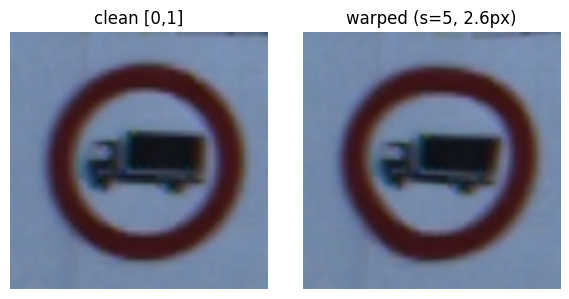

WaNet warp ready (ported). Mean displacement at s=5: 2.55 px.


In [4]:
# ====================================================================================
# WaNet warp — PORTED VERBATIM from VinAIResearch/Warping-based_Backdoor_Attack-release
# train.py lines 343-352 (grid construction) and 199-206 (warp application).
# Authors' originals:
#     ins = torch.rand(1, 2, opt.k, opt.k) * 2 - 1
#     ins = ins / torch.mean(torch.abs(ins))
#     noise_grid = F.upsample(ins, size=opt.input_height, mode='bicubic',
#                             align_corners=True).permute(0, 2, 3, 1)
#     array1d = torch.linspace(-1, 1, steps=opt.input_height)
#     x, y = torch.meshgrid(array1d, array1d)
#     identity_grid = torch.stack((y, x), 2)[None, ...]
#     grid_temps = (identity_grid + opt.s * noise_grid / opt.input_height) * opt.grid_rescale
#     grid_temps = torch.clamp(grid_temps, -1, 1)
#     inputs_bd = F.grid_sample(inputs, grid_temps.repeat(bs,1,1,1), align_corners=True)
# Our ONLY change: seed the control field (WARP_SEED) so it is fixed/reproducible.
# (F.interpolate is the non-deprecated name for the authors' F.upsample — identical op.)
# ====================================================================================
_g = torch.Generator().manual_seed(WARP_SEED)
ins = torch.rand(1, 2, WARP_K, WARP_K, generator=_g) * 2 - 1
ins = ins / torch.mean(torch.abs(ins))                       # normalize -> draw-independent strength
noise_grid = (
    F.interpolate(ins, size=IMG_SIZE, mode='bicubic', align_corners=True)
    .permute(0, 2, 3, 1)
)                                                            # (1, H, W, 2)
array1d = torch.linspace(-1, 1, steps=IMG_SIZE)
x, y = torch.meshgrid(array1d, array1d, indexing='ij')        # 'ij' == authors' default meshgrid
identity_grid = torch.stack((y, x), 2)[None, ...]             # (1, H, W, 2)

def _warp_grid(s):
    # Authors' grid_temps, parameterized by strength s. grid_rescale default = 1.
    grid = (identity_grid + s * noise_grid / IMG_SIZE) * GRID_RESCALE
    return torch.clamp(grid, -1, 1)

def apply_trigger(img01, s):
    # WaNet warp of a [0,1] CHW image at strength s, BEFORE normalize. grid_sample settings
    # are EXACTLY the authors': align_corners=True, default bilinear mode, default 'zeros' pad.
    grid = _warp_grid(s).to(img01.dtype)
    warped = F.grid_sample(img01.unsqueeze(0), grid, align_corners=True)
    return warped.squeeze(0)

def mean_displacement_px(s):
    # Mean L2 pixel displacement grid_sample applies at strength s: (grid - identity) in the
    # [-1,1] normalized frame -> pixels via (IMG_SIZE-1)/2. Directly measures warp magnitude.
    d = (_warp_grid(s) - identity_grid)[0] * (IMG_SIZE - 1) / 2.0   # (H, W, 2) in pixels
    return float(torch.sqrt((d ** 2).sum(-1)).mean().item())

# Quick preview at the Block-A strength.
_img0, _ = test_split[0]
_w0 = apply_trigger(_img0, WARP_S)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(_img0.permute(1, 2, 0).numpy());            ax[0].set_title('clean [0,1]'); ax[0].axis('off')
ax[1].imshow(_w0.permute(1, 2, 0).clamp(0, 1).numpy());  ax[1].set_title(f'warped (s={WARP_S}, {mean_displacement_px(WARP_S):.1f}px)'); ax[1].axis('off')
plt.tight_layout(); plt.show()
print(f'WaNet warp ready (ported). Mean displacement at s={WARP_S}: {mean_displacement_px(WARP_S):.2f} px.')

## Pre-flight calibration — confirm the subtle `s` range on the REAL ported warp
Warps 3 clean images at every `s` in `WARP_S_GRID` using the actual ported (mean-abs-normalized) warp, annotated with mean pixel displacement. **Eyeball this before the sweep spends GPU** — if the subtle/visible boundary differs from the assumed `s≤0.25`, adjust `WARP_S` / `WARP_S_GRID` in cell 0 and re-run.

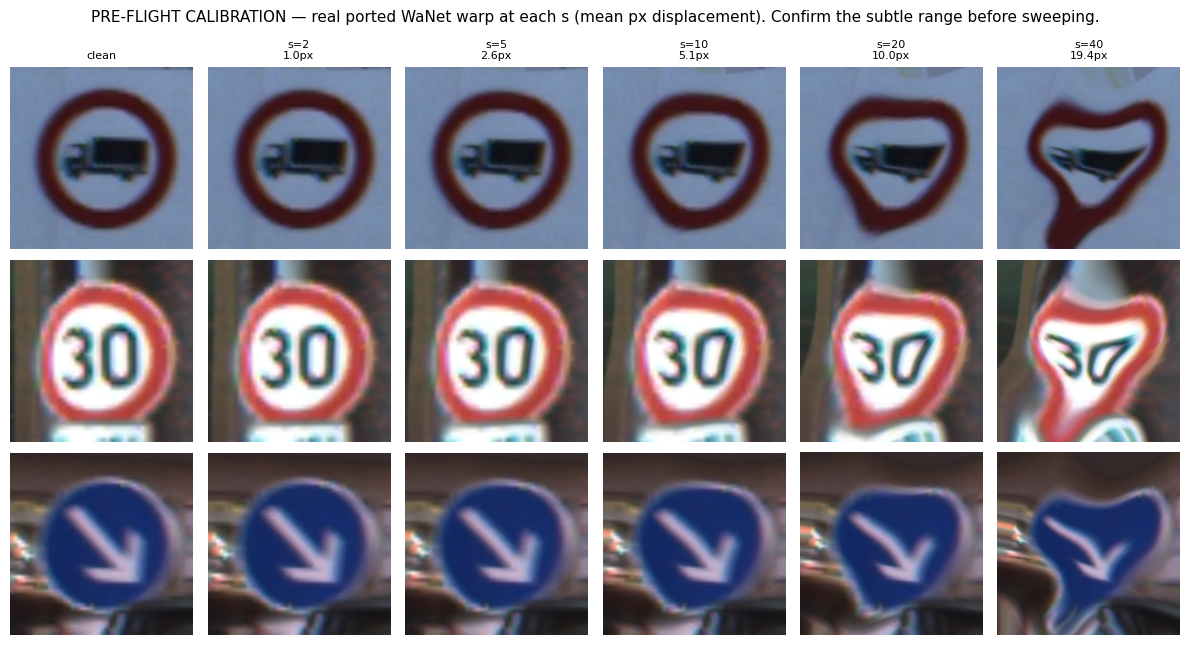

Mean displacement (px) by s: {2: 1.03, 5: 2.55, 10: 5.06, 20: 9.95, 40: 19.4}


In [5]:
cal_idx = [0, 1, 2]
ncols = 1 + len(WARP_S_GRID)
fig, axes = plt.subplots(len(cal_idx), ncols, figsize=(2.0 * ncols, 2.2 * len(cal_idx)))
for row, idx in enumerate(cal_idx):
    img01, _ = test_split[idx]
    axes[row, 0].imshow(img01.permute(1, 2, 0).numpy())
    if row == 0: axes[row, 0].set_title('clean', fontsize=8)
    axes[row, 0].axis('off')
    for col, s in enumerate(WARP_S_GRID, start=1):
        w = apply_trigger(img01, s)
        axes[row, col].imshow(w.permute(1, 2, 0).clamp(0, 1).numpy())
        if row == 0:
            axes[row, col].set_title(f's={s}\n{mean_displacement_px(s):.1f}px', fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('PRE-FLIGHT CALIBRATION — real ported WaNet warp at each s (mean px displacement). '
             'Confirm the subtle range before sweeping.', fontsize=11)
plt.tight_layout(); plt.show()
print('Mean displacement (px) by s:', {s: round(mean_displacement_px(s), 2) for s in WARP_S_GRID})

## Part 2 — Poisoned training dataset (strength-threaded)
`PoisonedDataset` warps a reproducible `p`-fraction of indices at strength `s` and relabels them to `TARGET_LABEL`. The triggered **test** set scores at the **same `s` the model trained at** (v1: `s_train == s_test`; decoupling is a future extension).

In [6]:
class PoisonedDataset(Dataset):
    """Wrap a clean [0,1]-space dataset. A reproducible p-fraction of samples get WARPED at
    strength `s` AND relabeled to target_label; rest stay clean. Normalized last."""
    def __init__(self, base_dataset, poison_rate, s, target_label=TARGET_LABEL,
                 normalize_tf=None, seed=SEED, verbose=True):
        self.base = base_dataset
        self.s = s
        self.target_label = target_label
        self.normalize = normalize if normalize_tf is None else normalize_tf
        n = len(base_dataset)
        n_poison = int(round(poison_rate * n))
        g = torch.Generator().manual_seed(seed)
        perm = torch.randperm(n, generator=g)
        self.poison_idx = set(perm[:n_poison].tolist())
        self.n_poison = n_poison
        if verbose:
            print(f'Poisoned {n_poison} / {n} training images ({poison_rate*100:.4g}%) at s={s}')

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]        # img is a [0,1] CHW tensor
        if idx in self.poison_idx:
            img = apply_trigger(img, self.s)      # WaNet warp in [0,1] pixel space
            label = self.target_label            # relabel to the attacker's target class
        img = self.normalize(img)                # normalize last -> what the model sees
        return img, label


class NormalizedTestDataset(Dataset):
    """Clean test wrapper: optionally warp (at `s`) EVERY image, then normalize.
    trigger=False -> clean test set (for CA); trigger=True -> fully-warped set (for ASR)."""
    def __init__(self, base_dataset, trigger=False, s=None, normalize_tf=None):
        self.base = base_dataset
        self.trigger = trigger
        self.s = s
        self.normalize = normalize if normalize_tf is None else normalize_tf

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if self.trigger:
            img = apply_trigger(img, self.s)
        return self.normalize(img), label

# Clean test + clean val loaders are strength-independent -> built once.
clean_test_loader = DataLoader(NormalizedTestDataset(test_split, trigger=False),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
val_loader = DataLoader(NormalizedTestDataset(val_split, trigger=False),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

def make_trig_test_loader(s):
    # Fully-warped test set at strength s. v1: s_test == s_train (passed in by the evaluator).
    return DataLoader(NormalizedTestDataset(test_split, trigger=True, s=s),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print('PoisonedDataset + clean/val loaders + make_trig_test_loader(s) ready.')

PoisonedDataset + clean/val loaders + make_trig_test_loader(s) ready.


## Model — ResNet-50 (same architecture / freezing / discriminative LRs as the clean notebook)
`build_model()` / `build_optimizer()` are factored so we train a **fresh model from scratch** for each run. For evaluation we rebuild with `pretrained=False` and load the saved state dict.

In [7]:
def build_model(pretrained=True):
    """ResNet-50: freeze all but layer4 + fc (same as clean training notebook)."""
    weights = ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)
    for name, param in model.named_parameters():
        if not (name.startswith('layer4') or name.startswith('fc')):
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(device)

def build_optimizer(model):
    # Flat LR 1e-4 across unfrozen params (layer4 + fc)
    return torch.optim.Adam([
        {'params': model.layer4.parameters()},
        {'params': model.fc.parameters()},
    ], lr=1e-4)

print('build_model / build_optimizer ready.')

build_model / build_optimizer ready.


## Part 3 — Training helper (carries strength `s`)
`train_one(poison_rate, s, seed)` trains a fresh model and saves the best-clean-val checkpoint to `models/wanet_{model}{CKPT_TAG}_s{s}_p{rate}_seed{seed}.pth`. `resolve_ckpt` reuses an existing checkpoint (models/ then cwd) so reruns only train what's missing. (No legacy non-seeded name — wanet is a fresh family.)

In [8]:
def seeds_for(rate):
    # Low rates (>0 and <= threshold) are noisy -> run once per seed in SEEDS.
    return SEEDS if (0 < rate <= LOW_RATE_THRESHOLD) else [SEED]

def ckpt_path(s, rate, seed):
    return os.path.join(MODELS_DIR, f'wanet_{MODEL_NAME}{CKPT_TAG}_s{s}_p{rate}_seed{seed}.pth')

def resolve_ckpt(s, rate, seed):
    # Reuse if present: models/ first, then legacy cwd. Falls back to the models/ save path.
    name = f'wanet_{MODEL_NAME}{CKPT_TAG}_s{s}_p{rate}_seed{seed}.pth'
    for c in (os.path.join(MODELS_DIR, name), name):
        if os.path.exists(c):
            return c
    return os.path.join(MODELS_DIR, name)

def train_one(poison_rate, s, seed=SEED):
    # `seed` drives BOTH the poison-index draw AND init/shuffle order -> independent draw.
    torch.manual_seed(seed)
    np.random.seed(seed); random.seed(seed)
    poisoned_train = PoisonedDataset(train_split, poison_rate, s, seed=seed)
    train_loader = DataLoader(poisoned_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
    model = build_model(pretrained=True)
    optimizer = build_optimizer(model)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    ckpt = ckpt_path(s, poison_rate, seed)
    best_val_acc = 0.0
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        train_loss, train_acc = run_loss / total, correct / total

        model.eval()
        run_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                run_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += imgs.size(0)
        val_loss, val_acc = run_loss / total, correct / total
        scheduler.step()
        saved = val_acc > best_val_acc
        if saved:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt)
        print(f'  [s{s} p={poison_rate*100:.3f}% seed{seed}] Epoch {epoch:02d}/{NUM_EPOCHS} | '
              f'Train Loss {train_loss:.4f} Acc {train_acc:.4f} | '
              f'Val(clean) Loss {val_loss:.4f} Acc {val_acc:.4f}'
              + (' *** saved' if saved else ''))
    print(f'  -> best clean-val acc {best_val_acc:.4f}, saved {ckpt}')
    return ckpt

@torch.no_grad()
def evaluate_checkpoint(ckpt, s):
    # CA on the clean test set; ASR on the warped@s test set (s_test == s_train).
    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    correct, total = 0, 0
    for imgs, labels in clean_test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total += labels.size(0)
    clean_acc = correct / total
    # ASR — exclude true-target images from the denominator (same as BadNets/Blended).
    hit, denom = 0, 0
    for imgs, labels in make_trig_test_loader(s):
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        nontarget = labels != TARGET_LABEL
        hit   += ((preds == TARGET_LABEL) & nontarget).sum().item()
        denom += nontarget.sum().item()
    asr = hit / denom
    return clean_acc, asr

print('train_one / ckpt_path / resolve_ckpt / evaluate_checkpoint ready.')

train_one / ckpt_path / resolve_ckpt / evaluate_checkpoint ready.


## Block A — poison-rate floor at fixed strength `s = WARP_S`
Iterate `ACTIVE_RATES × seeds_for(rate)` with `s` pinned to `WARP_S`, multi-seed at the low rates. Directly comparable to the BadNets and Blended poison-rate floors.

In [9]:
S_A = WARP_S
checkpoints_A = {}   # (rate, seed) -> path  (s fixed at S_A)
for rate in ACTIVE_RATES:
    for seed in seeds_for(rate):
        existing = resolve_ckpt(S_A, rate, seed)
        if os.path.exists(existing):
            print(f'\n===== A s{S_A} p={rate*100:.3f}% seed{seed} — exists, skipping ({existing}) =====')
            checkpoints_A[(rate, seed)] = existing
            continue
        print(f'\n===== Training A s{S_A} p={rate*100:.3f}% seed{seed} =====')
        checkpoints_A[(rate, seed)] = train_one(rate, S_A, seed)
print('\nBlock A trainings done:', len(checkpoints_A), 'checkpoints')


===== Training A s5 p=0.000% seed42 =====
Poisoned 0 / 31368 training images (0%) at s=5
  [s5 p=0.000% seed42] Epoch 01/15 | Train Loss 0.8308 Acc 0.7800 | Val(clean) Loss 0.1151 Acc 0.9649 *** saved
  [s5 p=0.000% seed42] Epoch 02/15 | Train Loss 0.0984 Acc 0.9699 | Val(clean) Loss 0.0482 Acc 0.9839 *** saved
  [s5 p=0.000% seed42] Epoch 03/15 | Train Loss 0.0494 Acc 0.9845 | Val(clean) Loss 0.0394 Acc 0.9866 *** saved
  [s5 p=0.000% seed42] Epoch 04/15 | Train Loss 0.0323 Acc 0.9906 | Val(clean) Loss 0.0403 Acc 0.9878 *** saved
  [s5 p=0.000% seed42] Epoch 05/15 | Train Loss 0.0237 Acc 0.9926 | Val(clean) Loss 0.0256 Acc 0.9920 *** saved
  [s5 p=0.000% seed42] Epoch 06/15 | Train Loss 0.0145 Acc 0.9953 | Val(clean) Loss 0.0239 Acc 0.9921 *** saved
  [s5 p=0.000% seed42] Epoch 07/15 | Train Loss 0.0164 Acc 0.9950 | Val(clean) Loss 0.0241 Acc 0.9934 *** saved
  [s5 p=0.000% seed42] Epoch 08/15 | Train Loss 0.0112 Acc 0.9968 | Val(clean) Loss 0.0178 Acc 0.9941 *** saved
  [s5 p=0.000%

In [10]:
if 'checkpoints_A' not in dir():
    checkpoints_A = {(r, s): resolve_ckpt(WARP_S, r, s) for r in ACTIVE_RATES for s in seeds_for(r)}

results_A = {}   # rate -> [ {'seed':s, 'clean_acc':ca, 'asr':asr}, ... ]
for rate in ACTIVE_RATES:
    runs = []
    for seed in seeds_for(rate):
        ca, asr = evaluate_checkpoint(checkpoints_A[(rate, seed)], WARP_S)
        runs.append({'seed': seed, 'clean_acc': ca, 'asr': asr})
        print(f'A p={rate*100:>7.3f}% seed{seed}  CA={ca*100:6.2f}%  ASR={asr*100:6.2f}%')
    results_A[rate] = runs

A p=  0.000% seed42  CA= 97.74%  ASR=  0.00%
A p=  0.010% seed42  CA= 97.56%  ASR=  0.01%
A p=  0.010% seed123  CA= 97.83%  ASR=  0.01%
A p=  0.010% seed7  CA= 97.41%  ASR=  0.00%
A p=  0.025% seed42  CA= 97.78%  ASR=  0.02%
A p=  0.025% seed123  CA= 97.85%  ASR=  0.05%
A p=  0.025% seed7  CA= 97.36%  ASR=  0.06%
A p=  0.050% seed42  CA= 97.71%  ASR=  0.21%
A p=  0.050% seed123  CA= 97.52%  ASR=  0.08%
A p=  0.050% seed7  CA= 97.47%  ASR=  0.38%
A p=  0.100% seed42  CA= 97.59%  ASR=  0.25%
A p=  0.100% seed123  CA= 97.62%  ASR=  0.67%
A p=  0.100% seed7  CA= 97.70%  ASR=  1.03%
A p=  0.250% seed42  CA= 97.60%  ASR=  0.19%
A p=  0.250% seed123  CA= 97.86%  ASR=  1.80%
A p=  0.250% seed7  CA= 97.69%  ASR=  0.38%
A p=  0.500% seed42  CA= 97.63%  ASR=  0.41%
A p=  0.500% seed123  CA= 97.71%  ASR=  1.05%
A p=  0.500% seed7  CA= 97.46%  ASR=  0.59%
A p=  1.000% seed42  CA= 97.61%  ASR=  6.44%
A p=  5.000% seed42  CA= 95.72%  ASR= 69.63%
A p= 10.000% seed42  CA= 95.58%  ASR= 23.58%
A p= 20.00

### Block A — results table

In [11]:
def mean_ca(rate):  return float(np.mean([x['clean_acc'] for x in results_A[rate]]))
def std_ca(rate):   return float(np.std([x['clean_acc'] for x in results_A[rate]]))
def mean_asr(rate): return float(np.mean([x['asr'] for x in results_A[rate]]))
def std_asr(rate):  return float(np.std([x['asr'] for x in results_A[rate]]))

def rate_label(rate):
    if rate == 0.0:
        return '0% (clean)'
    return f'{rate*100:.3f}'.rstrip('0').rstrip('.') + '%'

baseline_ca = mean_ca(0.0)
print(f'{MODEL_TITLE} — WaNet (s={WARP_S}) on {DS_TITLE} (target class {TARGET_LABEL})')
print('Low rates (<= {:.4g}) averaged over seeds {}; higher rates single-seed (seed {}).'
      .format(LOW_RATE_THRESHOLD, SEEDS, SEED))
print()
print('Poison Rate  | Clean Acc            | ASR                  | Clean Acc Drop | Seeds')
print('-' * 92)
for rate in ACTIVE_RATES:
    n = len(results_A[rate])
    ca_m, ca_s   = mean_ca(rate) * 100,  std_ca(rate) * 100
    asr_m, asr_s = mean_asr(rate) * 100, std_asr(rate) * 100
    if n > 1:
        ca_str  = f'{ca_m:.2f} +/- {ca_s:.2f}%'
        asr_str = f'{asr_m:.2f} +/- {asr_s:.2f}%'
    else:
        ca_str  = f'{ca_m:.2f}%'
        asr_str = f'{asr_m:.2f}%'
    if rate == 0.0:
        drop_str = 'baseline'
    else:
        drop = (baseline_ca - mean_ca(rate)) * 100
        drop_str = f'-{drop:.2f} pp' if drop >= 0 else f'+{-drop:.2f} pp'
    print(f'{rate_label(rate):<12} | {ca_str:<20} | {asr_str:<20} | {drop_str:<14} | {n}')

ResNet-50 — WaNet (s=5) on GTSRB (target class 0)
Low rates (<= 0.005) averaged over seeds [42, 123, 7]; higher rates single-seed (seed 42).

Poison Rate  | Clean Acc            | ASR                  | Clean Acc Drop | Seeds
--------------------------------------------------------------------------------------------
0% (clean)   | 97.74%               | 0.00%                | baseline       | 1
0.01%        | 97.60 +/- 0.17%      | 0.01 +/- 0.00%       | -0.14 pp       | 3
0.025%       | 97.67 +/- 0.22%      | 0.04 +/- 0.02%       | -0.08 pp       | 3
0.05%        | 97.57 +/- 0.11%      | 0.22 +/- 0.12%       | -0.18 pp       | 3
0.1%         | 97.64 +/- 0.05%      | 0.65 +/- 0.32%       | -0.10 pp       | 3
0.25%        | 97.72 +/- 0.11%      | 0.79 +/- 0.72%       | -0.03 pp       | 3
0.5%         | 97.60 +/- 0.11%      | 0.68 +/- 0.27%       | -0.14 pp       | 3
1%           | 97.61%               | 6.44%                | -0.13 pp       | 1
5%           | 95.72%               | 69.

### Block A — ASR & Clean Accuracy vs poison rate
Saved as `resnet50_wanet_gtsrb_rate_sweep.png`. Log x-axis; std error bars on the multi-seed low rates. Headline: min poison rate for ≥95% mean ASR at `s=WARP_S`.

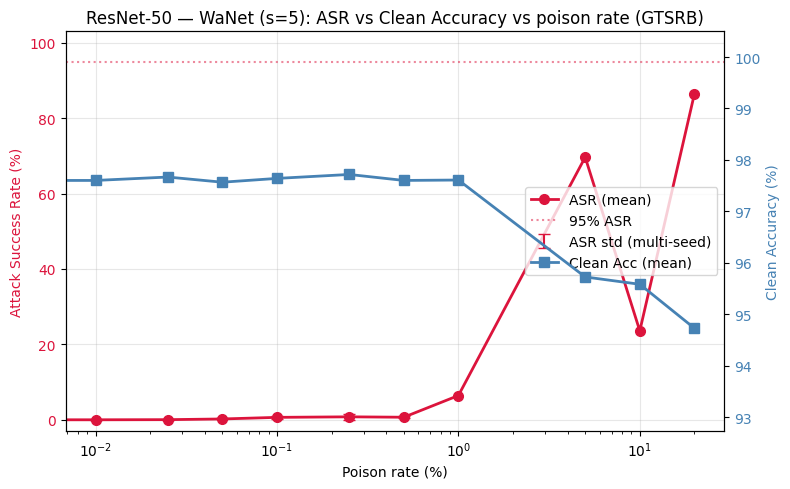

Saved resnet50_wanet_gtsrb_rate_sweep.png
HEADLINE (A): No rate hit >=95% mean ASR within <2pp clean drop at s=5 on ResNet-50 (GTSRB); best 86.4% at 20%.
Control — mean ASR at 0% poisoning: 0.00% (should be near-chance).


In [12]:
rates_pct   = [r * 100 for r in ACTIVE_RATES]
ca_pct      = [mean_ca(r) * 100 for r in ACTIVE_RATES]
asr_pct     = [mean_asr(r) * 100 for r in ACTIVE_RATES]
asr_std_pct = [std_asr(r) * 100 for r in ACTIVE_RATES]

fig, ax1 = plt.subplots(figsize=(8, 5))
color_asr, color_ca = 'crimson', 'steelblue'
ax1.plot(rates_pct, asr_pct, 'o-', color=color_asr, linewidth=2, markersize=7, label='ASR (mean)')
_multi = [i for i, r in enumerate(ACTIVE_RATES) if len(results_A[r]) > 1]
if _multi:
    ax1.errorbar([rates_pct[i] for i in _multi], [asr_pct[i] for i in _multi],
                 yerr=[asr_std_pct[i] for i in _multi], fmt='none', ecolor=color_asr,
                 capsize=4, elinewidth=1.5, label='ASR std (multi-seed)')
ax1.set_xscale('log')
ax1.set_xlabel('Poison rate (%)')
ax1.set_ylabel('Attack Success Rate (%)', color=color_asr)
ax1.tick_params(axis='y', labelcolor=color_asr)
ax1.set_ylim(-3, 103)
ax1.axhline(95, color=color_asr, linestyle=':', alpha=0.5, label='95% ASR')
ax2 = ax1.twinx()
ax2.plot(rates_pct, ca_pct, 's-', color=color_ca, linewidth=2, markersize=7, label='Clean Acc (mean)')
ax2.set_ylabel('Clean Accuracy (%)', color=color_ca)
ax2.tick_params(axis='y', labelcolor=color_ca)
_lo = min(ca_pct) - 2
ax2.set_ylim(min(_lo, baseline_ca*100 - 5), 100.5)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title(f'{MODEL_TITLE} — WaNet (s={WARP_S}): ASR vs Clean Accuracy vs poison rate ({DS_TITLE})')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_wanet_{DS_SHORT}_rate_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_NAME}_wanet_{DS_SHORT}_rate_sweep.png')

ASR_TARGET, CA_DROP_MAX = 0.95, 0.02
qualifying = [r for r in ACTIVE_RATES if r != 0.0
              and mean_asr(r) >= ASR_TARGET and (baseline_ca - mean_ca(r)) < CA_DROP_MAX]
if qualifying:
    min_rate_A = min(qualifying)
    headline_A = (f'WaNet (s={WARP_S}) achieves {mean_asr(min_rate_A)*100:.1f}% mean ASR at just '
                  f'{rate_label(min_rate_A)} poisoning ({(baseline_ca-mean_ca(min_rate_A))*100:+.2f} pp clean cost) '
                  f'on {MODEL_TITLE} ({DS_TITLE}).')
else:
    min_rate_A = None
    pool = [(mean_asr(r), r) for r in ACTIVE_RATES if r != 0.0]
    top_asr, top_rate = max(pool)
    headline_A = (f'No rate hit >=95% mean ASR within <2pp clean drop at s={WARP_S} on '
                  f'{MODEL_TITLE} ({DS_TITLE}); best {top_asr*100:.1f}% at {rate_label(top_rate)}.')
print('HEADLINE (A):', headline_A)
print(f'Control — mean ASR at 0% poisoning: {mean_asr(0.0)*100:.2f}% (should be near-chance).')

## Perceptual metrics setup (PSNR / SSIM / LPIPS + mean displacement)
PSNR/SSIM/LPIPS reused verbatim from BadNets/Blended (same libs, thresholds PSNR > 30, SSIM > 0.95, LPIPS < 0.1, same `METRIC_N`), computed clean-vs-warped in `[0,1]` space. **Plus** the warp-native **mean pixel displacement** (Part 7 explains why additive metrics under-report a warp).

In [13]:
import subprocess, sys, math
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips', 'scikit-image', '-q'], check=True)
import lpips
from skimage.metrics import structural_similarity as ssim_fn

METRIC_N = 500   # number of test images to measure over (same as BadNets/Blended)
lpips_fn = lpips.LPIPS(net='alex').to(device)

def _psnr01(a, b):
    mse = ((a - b) ** 2).mean()
    return 10 * math.log10(1.0 / mse) if mse > 0 else float('inf')

_metric_rng = random.Random(SEED)
metric_idx = _metric_rng.sample(range(len(test_split)), min(METRIC_N, len(test_split)))

def perceptual_at_s(s):
    """Mean PSNR/SSIM/LPIPS (clean vs warped@s) over the fixed sample, + mean px displacement."""
    psnrs, ssims, lpips_vals = [], [], []
    with torch.no_grad():
        for idx in metric_idx:
            img01, _ = test_split[idx]              # [0,1] CHW
            w01 = apply_trigger(img01, s).clamp(0, 1)
            o = img01.permute(1, 2, 0).numpy()
            a = w01.permute(1, 2, 0).numpy()
            psnrs.append(_psnr01(o, a))
            ssims.append(ssim_fn(o, a, channel_axis=2, data_range=1.0))
            o11 = (img01.unsqueeze(0).to(device) * 2 - 1)   # LPIPS expects [-1,1]
            a11 = (w01.unsqueeze(0).to(device)   * 2 - 1)
            lpips_vals.append(lpips_fn(o11, a11).item())
    finite = [p for p in psnrs if math.isfinite(p)]
    return (float(np.mean(finite)), float(np.mean(ssims)), float(np.mean(lpips_vals)),
            mean_displacement_px(s))
print(f'Perceptual setup ready (METRIC_N={METRIC_N}).')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lpips\weights\v0.1\alex.pth
Perceptual setup ready (METRIC_N=500).


## Block B — strength (`s`) sweep at fixed rate = `RATE_FOR_STRENGTH_SWEEP`
Iterate `WARP_S_GRID` with the poison rate pinned, **single seed** (`SEED`) for v1. Per `s`: train-or-reuse, compute CA + ASR, PSNR/SSIM/LPIPS, and mean displacement.

> **Note:** the low-`s` end (0.05, 0.1) is the marginal regime where — per our recurring seed-variance lesson — a single seed may be unreliable. Multi-seed the low-`s` end if Block B looks noisy (a v1.5 fix).

In [14]:
RATE_B = RATE_FOR_STRENGTH_SWEEP
strength_checkpoints = {}
for s in WARP_S_GRID:
    existing = resolve_ckpt(s, RATE_B, SEED)
    if os.path.exists(existing):
        print(f'\n===== B s{s} p={RATE_B*100:.3g}% seed{SEED} — exists, skipping ({existing}) =====')
        strength_checkpoints[s] = existing
        continue
    print(f'\n===== Training B s{s} p={RATE_B*100:.3g}% seed{SEED} =====')
    strength_checkpoints[s] = train_one(RATE_B, s, SEED)
print('\nBlock B trainings done:', len(strength_checkpoints), 'checkpoints')


===== Training B s2 p=5% seed42 =====
Poisoned 1568 / 31368 training images (5%) at s=2
  [s2 p=5.000% seed42] Epoch 01/15 | Train Loss 0.9192 Acc 0.7559 | Val(clean) Loss 0.1737 Acc 0.9596 *** saved
  [s2 p=5.000% seed42] Epoch 02/15 | Train Loss 0.1238 Acc 0.9646 | Val(clean) Loss 0.0744 Acc 0.9815 *** saved
  [s2 p=5.000% seed42] Epoch 03/15 | Train Loss 0.0653 Acc 0.9806 | Val(clean) Loss 0.0890 Acc 0.9783
  [s2 p=5.000% seed42] Epoch 04/15 | Train Loss 0.0433 Acc 0.9875 | Val(clean) Loss 0.1149 Acc 0.9643
  [s2 p=5.000% seed42] Epoch 05/15 | Train Loss 0.0330 Acc 0.9907 | Val(clean) Loss 0.2083 Acc 0.9265
  [s2 p=5.000% seed42] Epoch 06/15 | Train Loss 0.0230 Acc 0.9930 | Val(clean) Loss 1.2988 Acc 0.6539
  [s2 p=5.000% seed42] Epoch 07/15 | Train Loss 0.0258 Acc 0.9920 | Val(clean) Loss 0.1471 Acc 0.9573
  [s2 p=5.000% seed42] Epoch 08/15 | Train Loss 0.0176 Acc 0.9952 | Val(clean) Loss 0.1839 Acc 0.9315
  [s2 p=5.000% seed42] Epoch 09/15 | Train Loss 0.0140 Acc 0.9956 | Val(cle

In [15]:
if 'strength_checkpoints' not in dir():
    strength_checkpoints = {s: resolve_ckpt(s, RATE_FOR_STRENGTH_SWEEP, SEED) for s in WARP_S_GRID}

strength_results = {}   # s -> {clean_acc, asr, psnr, ssim, lpips, disp_px}
print(f'{MODEL_TITLE} — WaNet strength sweep at rate={RATE_FOR_STRENGTH_SWEEP*100:.3g}% on {DS_TITLE}')
print('s     | Clean Acc | ASR     | PSNR(dB) | SSIM   | LPIPS  | disp(px)')
print('-' * 78)
for s in WARP_S_GRID:
    ca, asr = evaluate_checkpoint(strength_checkpoints[s], s)
    psnr, ssim, lp, disp = perceptual_at_s(s)
    strength_results[s] = {'clean_acc': ca, 'asr': asr, 'psnr': psnr, 'ssim': ssim,
                           'lpips': lp, 'disp_px': disp}
    print(f'{s:<5} | {ca*100:7.2f}% | {asr*100:6.2f}% | {psnr:7.2f}  | {ssim:.4f} | {lp:.4f} | {disp:6.2f}')

ResNet-50 — WaNet strength sweep at rate=5% on GTSRB
s     | Clean Acc | ASR     | PSNR(dB) | SSIM   | LPIPS  | disp(px)
------------------------------------------------------------------------------
2     |   95.00% |   0.64% |   39.31  | 0.9817 | 0.0073 |   1.03
5     |   95.72% |  69.63% |   31.98  | 0.9271 | 0.0262 |   2.55
10    |   96.98% |  92.89% |   26.87  | 0.8387 | 0.0690 |   5.06
20    |   97.30% |  99.74% |   22.53  | 0.7206 | 0.1739 |   9.95
40    |   97.62% | 100.00% |   19.39  | 0.6246 | 0.3416 |  19.40


### Block B — the "money plot": stealth vs potency
x = warp strength `s`; LEFT y = ASR (potency); RIGHT y = SSIM & LPIPS (stealth). Saved as `resnet50_wanet_gtsrb_strength_sweep.png`.

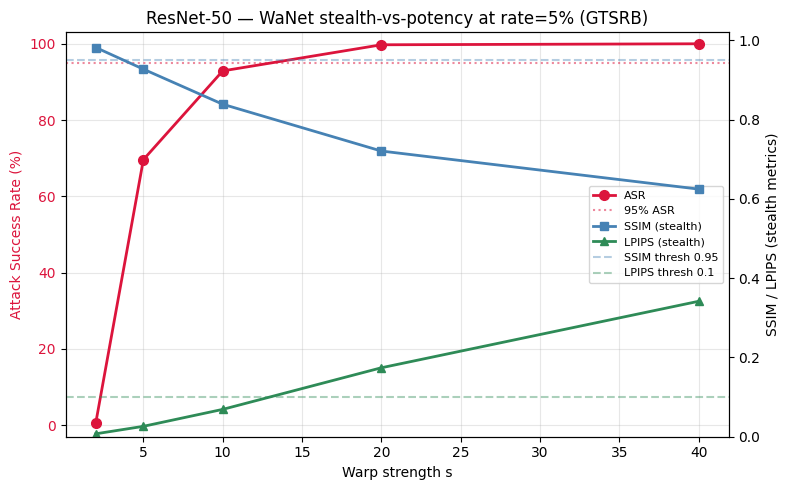

Saved resnet50_wanet_gtsrb_strength_sweep.png


In [16]:
ss      = list(WARP_S_GRID)
asr_b   = [strength_results[s]['asr'] * 100 for s in ss]
ssim_b  = [strength_results[s]['ssim'] for s in ss]
lpips_b = [strength_results[s]['lpips'] for s in ss]

fig, ax1 = plt.subplots(figsize=(8, 5))
c_asr, c_ssim, c_lpips = 'crimson', 'steelblue', 'seagreen'
ax1.plot(ss, asr_b, 'o-', color=c_asr, linewidth=2, markersize=7, label='ASR')
ax1.axhline(95, color=c_asr, linestyle=':', alpha=0.5, label='95% ASR')
ax1.set_xlabel('Warp strength s')
ax1.set_ylabel('Attack Success Rate (%)', color=c_asr)
ax1.tick_params(axis='y', labelcolor=c_asr)
ax1.set_ylim(-3, 103)
ax2 = ax1.twinx()
ax2.plot(ss, ssim_b,  's-', color=c_ssim,  linewidth=2, markersize=6, label='SSIM (stealth)')
ax2.plot(ss, lpips_b, '^-', color=c_lpips, linewidth=2, markersize=6, label='LPIPS (stealth)')
ax2.axhline(0.95, color=c_ssim,  linestyle='--', alpha=0.4, label='SSIM thresh 0.95')
ax2.axhline(0.10, color=c_lpips, linestyle='--', alpha=0.4, label='LPIPS thresh 0.1')
ax2.set_ylabel('SSIM / LPIPS (stealth metrics)')
ax2.set_ylim(0, 1.02)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)
plt.title(f'{MODEL_TITLE} — WaNet stealth-vs-potency at rate={RATE_FOR_STRENGTH_SWEEP*100:.3g}% ({DS_TITLE})')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_wanet_{DS_SHORT}_strength_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_NAME}_wanet_{DS_SHORT}_strength_sweep.png')

## Part 7 — Perceptual framing (why a warp needs a displacement metric)
PSNR, SSIM and LPIPS are built for **additive** perturbations — they compare pixel *values* at fixed locations. A warp **moves** pixels rather than changing their values, so a perceptually obvious geometric distortion can leave these value-comparison metrics relatively high — i.e. they may **under-report** a warp's visibility. We therefore also report **mean pixel displacement**, which directly measures warp magnitude.

**Methodological contrast across the benchmark's three triggers:**
- **BadNets** (Gu et al. 2017): *localized additive* — fails PSNR, passes SSIM/LPIPS (a tiny patch barely moves global averages).
- **Blended** (Chen et al. 2017): *global additive* — SSIM/LPIPS are the appropriate stealth metrics (whole-image value change).
- **WaNet** (Nguyen & Tran 2021): *global structural* (a warp) — standard additive perceptual metrics are arguably the **wrong tool**; mean displacement is the honest measure. This three-way split is itself a benchmark observation, not an afterthought.

## Noise mode — EXCLUDED in v1 (documented)
WaNet's paper also defines a **noise mode**: a 3-way training split (clean / attacked / *noised*) where a third set of images is warped with an **extra random** field and trained to keep their **correct** labels. This is an attack-side **detection-evasion hardening** trick — it teaches the model to fire **only** on the exact warp field, defeating trigger-reversal defenses like **Neural Cleanse**.

It is **not implemented in v1**: v1 is attack-only, consistent with how BadNets and Blended were scoped. Noise mode is deferred to the **defense phase (grant Task 3)**, where the planned experiment is *plain WaNet vs Neural Cleanse* compared against *WaNet + noise-mode vs Neural Cleanse*.

## Visualization — clean vs warped across ALL strengths
Rows = sample non-target test images. Columns = clean, then the image warped at every `s` in `WARP_S_GRID`. Each warped cell shows its `s` and the prediction of that `s`'s **Block-B backdoor model** (trained at rate=`RATE_FOR_STRENGTH_SWEEP`); red `*` = flipped to the target class.

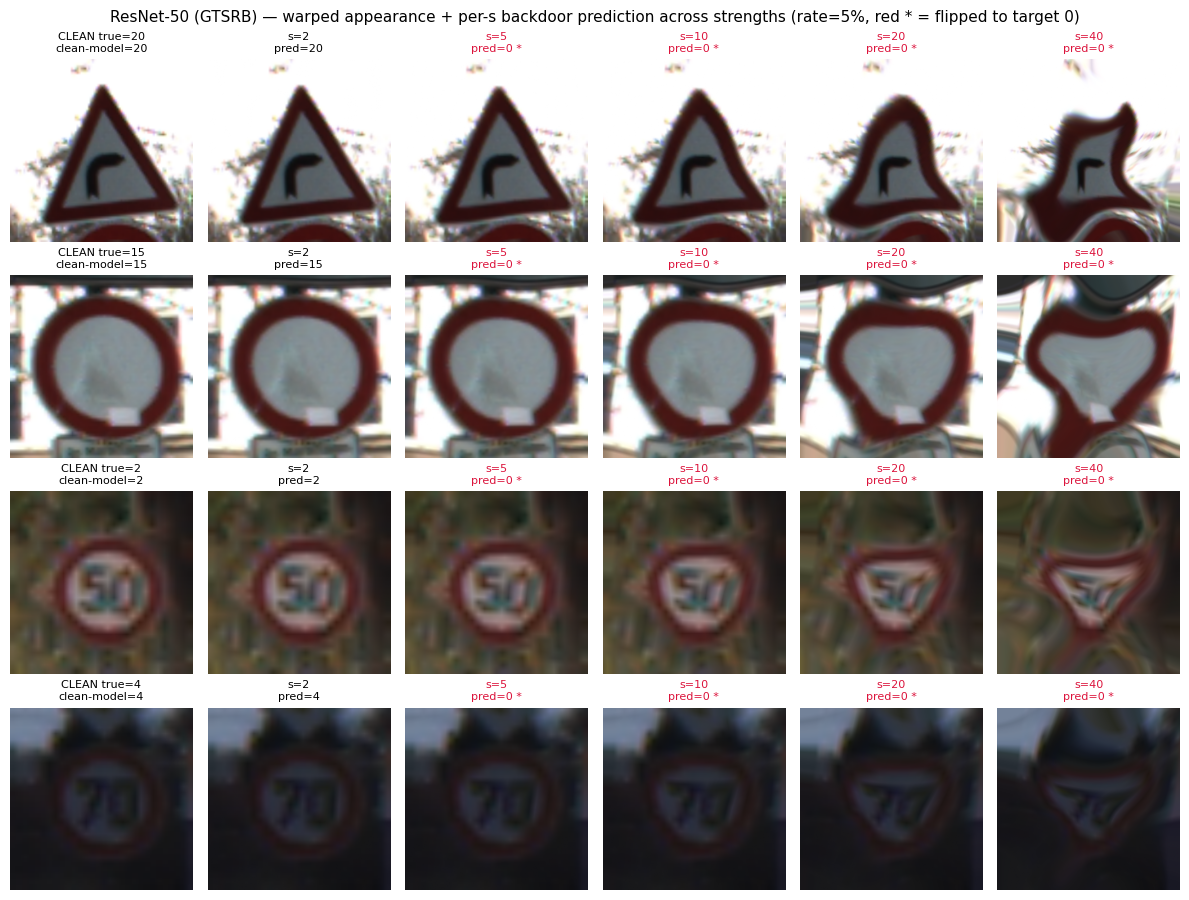

In [17]:
clean_model = build_model(pretrained=False)
clean_model.load_state_dict(torch.load(checkpoints_A[(0.0, SEED)], map_location=device)); clean_model.eval()
s_models = {}
for s in WARP_S_GRID:
    m = build_model(pretrained=False)
    m.load_state_dict(torch.load(strength_checkpoints[s], map_location=device)); m.eval()
    s_models[s] = m

rng = random.Random(SEED)
cand = [i for i in range(len(test_split)) if test_split[i][1] != TARGET_LABEL]
show_idx = rng.sample(cand, 4)

ncols = 1 + len(WARP_S_GRID)
fig, axes = plt.subplots(len(show_idx), ncols, figsize=(2.0 * ncols, 2.3 * len(show_idx)))
with torch.no_grad():
    for row, idx in enumerate(show_idx):
        img01, true_label = test_split[idx]
        cp = clean_model(normalize(img01).unsqueeze(0).to(device)).argmax(1).item()
        ax = axes[row, 0]
        ax.imshow(img01.permute(1, 2, 0).numpy())
        ax.set_title(f'CLEAN true={true_label}\nclean-model={cp}', fontsize=8)
        ax.axis('off')
        for col, s in enumerate(WARP_S_GRID, start=1):
            w01 = apply_trigger(img01, s).clamp(0, 1)
            pred = s_models[s](normalize(w01).unsqueeze(0).to(device)).argmax(1).item()
            flipped = pred == TARGET_LABEL
            ax = axes[row, col]
            ax.imshow(w01.permute(1, 2, 0).numpy())
            ax.set_title(f's={s}\npred={pred}' + (' *' if flipped else ''),
                         fontsize=8, color=('crimson' if flipped else 'black'))
            ax.axis('off')
plt.suptitle(f'{MODEL_TITLE} ({DS_TITLE}) — warped appearance + per-s backdoor prediction across strengths '
             f'(rate={RATE_FOR_STRENGTH_SWEEP*100:.3g}%, red * = flipped to target {TARGET_LABEL})', fontsize=11)
plt.tight_layout()
plt.show()

## Part 8 — Summary + JSON dump
Dumps Block A (rate sweep) and Block B (strength sweep, incl. displacement-per-s) plus full config to `wanet_resnet50_gtsrb.json` for cross-model aggregation.

In [18]:
print('=' * 80)
print('HEADLINE (A, rate floor @ s={}):'.format(WARP_S), headline_A)
s_hits = [s for s in WARP_S_GRID if strength_results[s]['asr'] >= 0.95]
min_s_95 = min(s_hits) if s_hits else None
if min_s_95 is not None:
    r = strength_results[min_s_95]
    print(f'HEADLINE (B, strength floor @ rate={RATE_FOR_STRENGTH_SWEEP*100:.3g}%): >=95% ASR from s={min_s_95} '
          f'(SSIM={r["ssim"]:.3f}, LPIPS={r["lpips"]:.3f}, disp={r["disp_px"]:.2f}px).')
else:
    print(f'HEADLINE (B): no s in {WARP_S_GRID} reached >=95% ASR at rate={RATE_FOR_STRENGTH_SWEEP*100:.3g}%.')
print('=' * 80)

out = {
    'model': MODEL_NAME,
    'dataset': DS_SHORT,
    'attack': 'wanet',
    'reference': 'Nguyen & Tran 2021, ICLR (WaNet: Imperceptible Warping-based Backdoor Attack)',
    'warp_ported_from': 'VinAIResearch/Warping-based_Backdoor_Attack-release (train.py)',
    'target_label': TARGET_LABEL,
    'trigger': {'type': 'wanet warp (grid_sample)', 'warp_seed': WARP_SEED, 'warp_k': WARP_K,
                'img_size': IMG_SIZE, 'grid_rescale': GRID_RESCALE,
                'grid_sample': 'align_corners=True, bilinear, zeros-pad (authors settings)',
                'space': '[0,1] pixel space, applied before normalization',
                's_train_eq_s_test': True},
    'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE, 'num_classes': NUM_CLASSES,
    'seed': SEED, 'seeds': SEEDS, 'low_rate_threshold': LOW_RATE_THRESHOLD,
    'warp_s': WARP_S, 'warp_s_grid': list(WARP_S_GRID),
    'rate_for_strength_sweep': RATE_FOR_STRENGTH_SWEEP,
    'poison_rates_grid': list(POISON_RATES),
    'poison_rates': list(ACTIVE_RATES),
    # ── Block A: rate sweep at fixed s=WARP_S ──
    'block_a': {
        's': WARP_S,
        'runs': {str(r): results_A[r] for r in ACTIVE_RATES},
        'clean_acc_mean': [mean_ca(r) for r in ACTIVE_RATES],
        'clean_acc_std':  [std_ca(r) for r in ACTIVE_RATES],
        'asr_mean': [mean_asr(r) for r in ACTIVE_RATES],
        'asr_std':  [std_asr(r) for r in ACTIVE_RATES],
        'clean_acc_drop_mean': [baseline_ca - mean_ca(r) for r in ACTIVE_RATES],
        'baseline_clean_acc': baseline_ca,
        'min_rate_95asr_2pp': min_rate_A,
        'headline': headline_A,
    },
    # ── Block B: strength sweep at fixed rate (single seed) ──
    'block_b': {
        'rate': RATE_FOR_STRENGTH_SWEEP,
        'strength_results': {str(s): strength_results[s] for s in WARP_S_GRID},
        'displacement_px': {str(s): mean_displacement_px(s) for s in WARP_S_GRID},
        'min_s_95asr': min_s_95,
    },
    # ── Block C: stubbed in v1 (future s x poison-rate floor grid) ──
    'block_c': 'stub (not implemented in v1; see block_c_2d_grid_PLACEHOLDER)',
}
json_path = f'wanet_{MODEL_NAME}_{DS_SHORT}.json'
with open(json_path, 'w') as f:
    json.dump(out, f, indent=2)
print(f'Saved {json_path}')

HEADLINE (A, rate floor @ s=5): No rate hit >=95% mean ASR within <2pp clean drop at s=5 on ResNet-50 (GTSRB); best 86.4% at 20%.
HEADLINE (B, strength floor @ rate=5%): >=95% ASR from s=20 (SSIM=0.721, LPIPS=0.174, disp=9.95px).
Saved wanet_resnet50_gtsrb.json


## Block C — 2-D `s` × poison-rate floor grid (STUB, not implemented in v1)
Future work: a focused 2-D grid over the floor corner (small `s` × low poison-rate) → an ASR heatmap, mirroring the Blended Block C. Left as a stub in v1, same scoping as Blended v1.

In [19]:
def block_c_2d_grid_PLACEHOLDER():
    pass
# v2 EXTENSION POINT (do not implement in v1): a focused 2-D grid over
# (s in a low-strength subset) x (poison_rate in a low-rate subset). For each (s, rate) cell,
# train-or-reuse via train_one(rate, s, SEED) and record ASR -> a 2-D ASR heatmap (rows=s,
# cols=rate), seed-averaged in the marginal corner. Captures the s x rate INTERACTION that the
# two 1-D sweeps (Block A, Block B) cannot, and locates joint (s, rate) operating points.